<a href="https://colab.research.google.com/github/melia1702/Pertemuan-ketigabelas/blob/main/LATIHAN_TAMBAHAN_MG_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


PERBANDINGAN KNN vs SVM

Model           CV Acc     Test Acc   Precision  Recall     F1-Score  
----------------------------------------------------------------------
KNN (k=5)       0.9524     0.9111     0.9298     0.9111     0.9095    
SVM Linear      0.9714     0.9111     0.9155     0.9111     0.9107    
SVM RBF         0.9714     0.9333     0.9345     0.9333     0.9333    


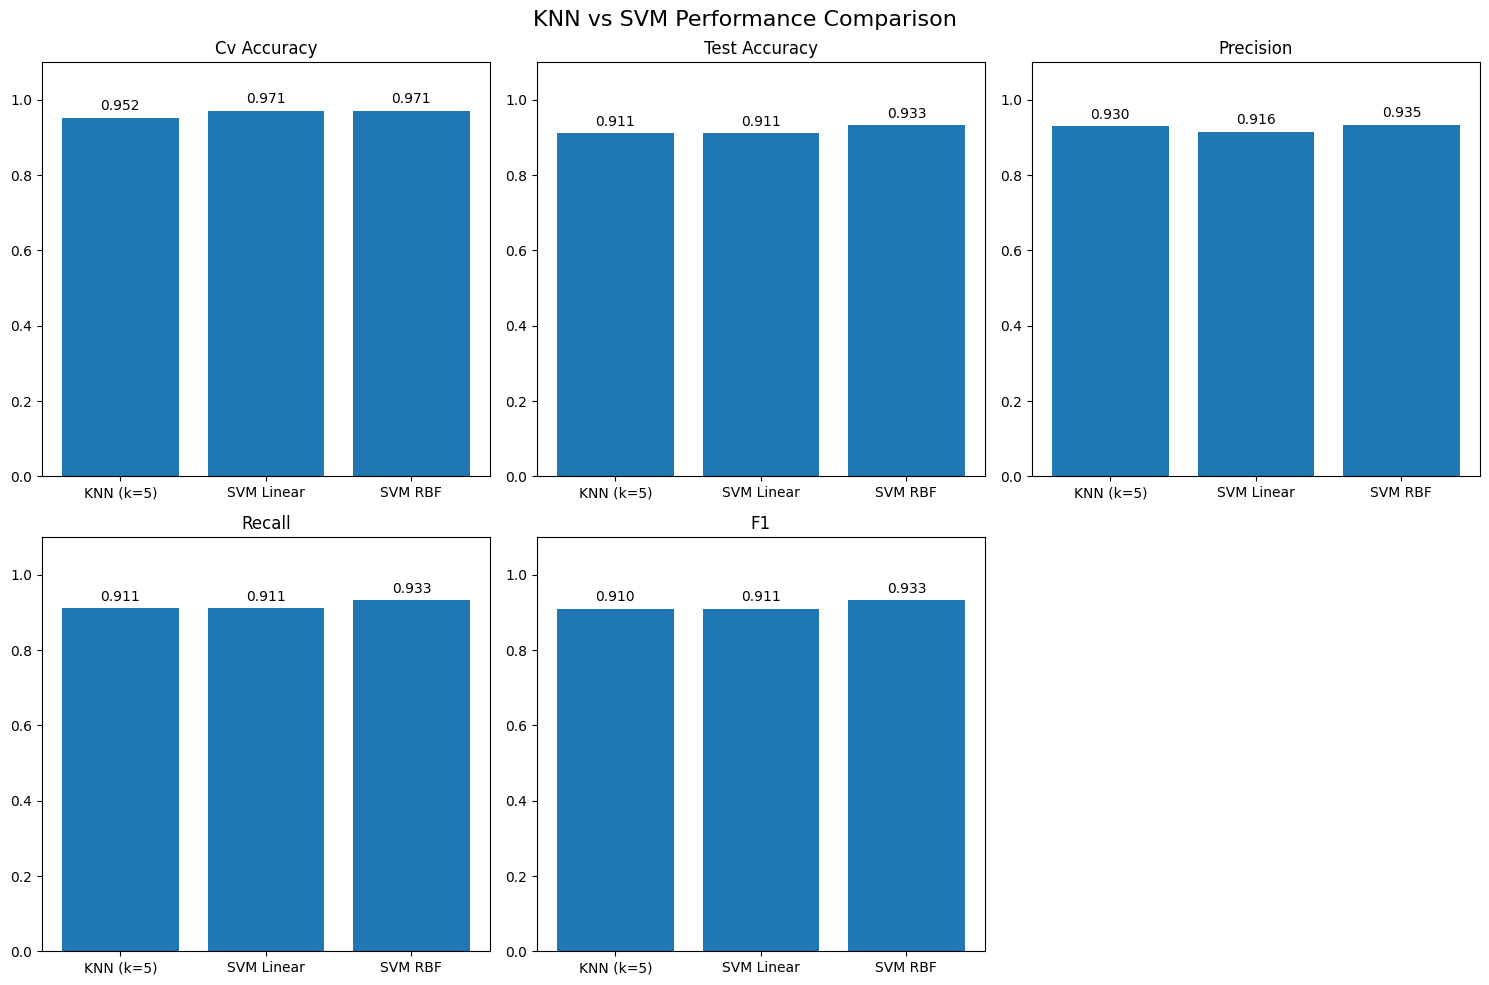

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn import svm

def compare_knn_svm():
    print("\nPERBANDINGAN KNN vs SVM")
    print("=" * 40)

    # =========================
    # LOAD DATASET
    # =========================
    from sklearn.datasets import load_iris
    iris = load_iris()

    X = iris.data
    y = iris.target

    # =========================
    # SPLIT DATA
    # =========================
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # =========================
    # SCALING
    # =========================
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # =========================
    # MODEL
    # =========================
    knn = KNeighborsClassifier(n_neighbors=5)
    svm_linear = svm.SVC(kernel='linear', C=1.0, random_state=42)
    svm_rbf = svm.SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

    models = {
        'KNN (k=5)': knn,
        'SVM Linear': svm_linear,
        'SVM RBF': svm_rbf
    }

    results = {}

    # =========================
    # TRAIN & EVALUASI
    # =========================
    from sklearn.metrics import precision_score, recall_score, f1_score

    for name, model in models.items():
        # Cross-validation
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

        # Training
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        # Metrics
        accuracy = model.score(X_test_scaled, y_test)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        results[name] = {
            'cv_accuracy': cv_scores.mean(),
            'test_accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'model': model
        }

    # =========================
    # PRINT HASIL
    # =========================
    print(f"\n{'Model':<15} {'CV Acc':<10} {'Test Acc':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
    print("-" * 70)

    for name, result in results.items():
        print(f"{name:<15} {result['cv_accuracy']:<10.4f} {result['test_accuracy']:<10.4f} "
              f"{result['precision']:<10.4f} {result['recall']:<10.4f} {result['f1']:<10.4f}")

    # =========================
    # VISUALISASI
    # =========================
    model_names = list(models.keys())

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    metrics_list = ['cv_accuracy', 'test_accuracy', 'precision', 'recall', 'f1']

    for idx, metric in enumerate(metrics_list):
        values = [results[name][metric] for name in model_names]

        bars = axes[idx].bar(model_names, values)
        axes[idx].set_title(metric.replace('_', ' ').title())
        axes[idx].set_ylim(0, 1.1)

        for bar, value in zip(bars, values):
            axes[idx].text(bar.get_x() + bar.get_width()/2,
                           bar.get_height() + 0.02,
                           f'{value:.3f}',
                           ha='center')

    # subplot kosong
    axes[-1].axis('off')

    plt.suptitle('KNN vs SVM Performance Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()

    return results

# RUN
comparison_results = compare_knn_svm()